In [1]:
%load_ext autoreload
%autoreload 2
from helpers import *
from SINDyModel import *

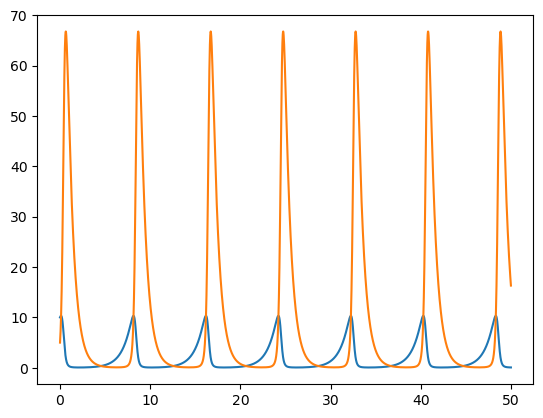

In [2]:
# make a specific Lotka-Volterra right-hand side function
lotka_volterra_rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)

dt_train = 0.01
t_span_train = (0, 50)

t_eval_train = np.arange(t_span_train[0], t_span_train[1] + dt_train, dt_train)
x0_train = (10, 5)
x_train = generate_training_data(lotka_volterra_rhs, x0_train, t_eval_train)

plt.plot(t_eval_train, x_train.T)
plt.show()

In [3]:
# evaluate how models perform with different time steps

t_span = (0, 50)
x0 = (10, 5)


poly_order = 5
threshold = 0.02 # NOTE: was 0.5 in demo notebook
noise_level = 0.01

# dts = np.linspace(0.01, 1, 10)
dts = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1]

t_evals = []
x_trains = []
models = []
x_preds = []
for dt in tqdm(dts):
    # generate evaluation time points
    t_eval = np.arange(t_span_train[0], t_span_train[1] + dt, dt)
    t_evals.append(t_eval)

    # generate training data
    x_train = generate_training_data(lotka_volterra_rhs, x0, t_eval)
    x_trains.append(x_train)
    
    # generate noisy data
    x_train_noisy = add_noise_to_data(x_train, noise_level)
    # generate the derivative of the noisy data
    x_dot_approx = dxdt(x_train_noisy, t_eval, kind="finite_difference", k=1)
    # create a SINDy model
    model = SINDyModel(threshold)
    # fit the SINDy model
    model.fit(x_train_noisy, x_dot_approx)
    models.append(model)
    
    x_pred = generate_model_prediction(model, x0, t_eval)
    x_preds.append(x_pred)

    # print the model if it failed to generate a prediction
    if x_pred is None:
        print(f"failed to generate model prediction for model trained with dt={dt}")


# print the models
for i in range(len(dts)):
    print(f"dt: {dts[i]}")
    models[i].print()
    print()

 43%|████▎     | 3/7 [00:07<00:10,  2.50s/it]c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\SINDyModel.py:9: RuntimeWarning: overflow encountered in power
  return lambda x: np.prod(np.power(x, powers), axis=1)
c:\Elliot\docs\education\college\2024-2025\MS project\MS-project\SINDyModel.py:124: RuntimeWarning: invalid value encountered in matmul
  x_dot = Theta @ self.Xi
c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\integrate\_ivp\lsoda.py:161: UserWarning: lsoda: Excess accuracy requested (tolerances too small).
  solver._y, solver.t = integrator.run(
 57%|█████▋    | 4/7 [00:15<00:13,  4.45s/it]

failed to generate model prediction for model trained with dt=0.1


c:\Users\Elliot\anaconda3\envs\ds312\Lib\site-packages\scipy\integrate\_ivp\lsoda.py:161: UserWarning: lsoda: Repeated error test failures (internal error).
  solver._y, solver.t = integrator.run(
 71%|███████▏  | 5/7 [00:34<00:19,  9.66s/it]

failed to generate model prediction for model trained with dt=0.2


100%|██████████| 7/7 [00:35<00:00,  5.06s/it]

dt: 0.01
x1 dot = + 0.99847 x0^1 + -0.10008 x0^1 x1^1 
x2 dot = + -1.50045 x1^1 + 0.75057 x0^1 x1^1 

dt: 0.02
x1 dot = + 0.99550 x0^1 + -0.09979 x0^1 x1^1 
x2 dot = + -1.49840 x1^1 + 0.74922 x0^1 x1^1 

dt: 0.05
x1 dot = + 0.99171 x0^1 + -0.09911 x0^1 x1^1 
x2 dot = + -1.48020 x1^1 + 0.05292 x0^1 + 0.73850 x0^1 x1^1 

dt: 0.1
x1 dot = + 0.96007 x0^1 + -0.09666 x0^1 x1^1 
x2 dot = + -0.32648 1 + -1.43280 x1^1 + -0.17286 x0^1 + 0.71392 x0^1 x1^1 + 0.05912 x0^2 

dt: 0.2
x1 dot = + -0.23348 1 + 1.27574 x0^1 + -0.08880 x0^1 x1^1 + -0.04591 x0^2 
x2 dot = + -1.95531 1 + -1.40102 x1^1 + 4.71875 x0^1 + 0.80592 x0^1 x1^1 + -1.73713 x0^2 + -0.02523 x0^2 x1^1 + 0.15365 x0^3 

dt: 0.5
x1 dot = + -0.17179 1 + -0.48909 x0^1 + -0.05291 x0^1 x1^1 + 0.65634 x0^2 + -0.06278 x0^3 
x2 dot = + 3.42317 1 + -2.59366 x1^1 + 0.03772 x1^2 + -7.11171 x0^1 + 0.27729 x0^1 x1^1 + 4.08127 x0^2 + -0.83687 x0^3 + 0.05759 x0^4 

dt: 1
x1 dot = + 0.10337 1 + -0.09676 x1^1 + 1.79915 x0^1 + -0.22082 x0^2 
x2 dot = + -2.

In [6]:
for i in range(len(dts)):
    if x_preds[i] is None:
        print(f"dt: {dts[i]:.6f}, failed to generate model prediction")
        continue
    rte = relative_trajectory_error(x_trains[i], x_preds[i])
    print(f"dt: {dts[i]:.6f}, relative trajectory error: {rte:.6f}")

dt: 0.010000, relative trajectory error: 0.003275
dt: 0.020000, relative trajectory error: 0.028953
dt: 0.050000, relative trajectory error: 0.772160
dt: 0.100000, failed to generate model prediction
dt: 0.200000, failed to generate model prediction
dt: 0.500000, relative trajectory error: 0.823510
dt: 1.000000, relative trajectory error: 0.939839


<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Elliot\AppData\Local\Temp\ipykernel_27300\473941855.py:22: SyntaxWarning: invalid escape sequence '\D'
  axs[row, col].set_title(f"$\Delta t$={dts[row]}")


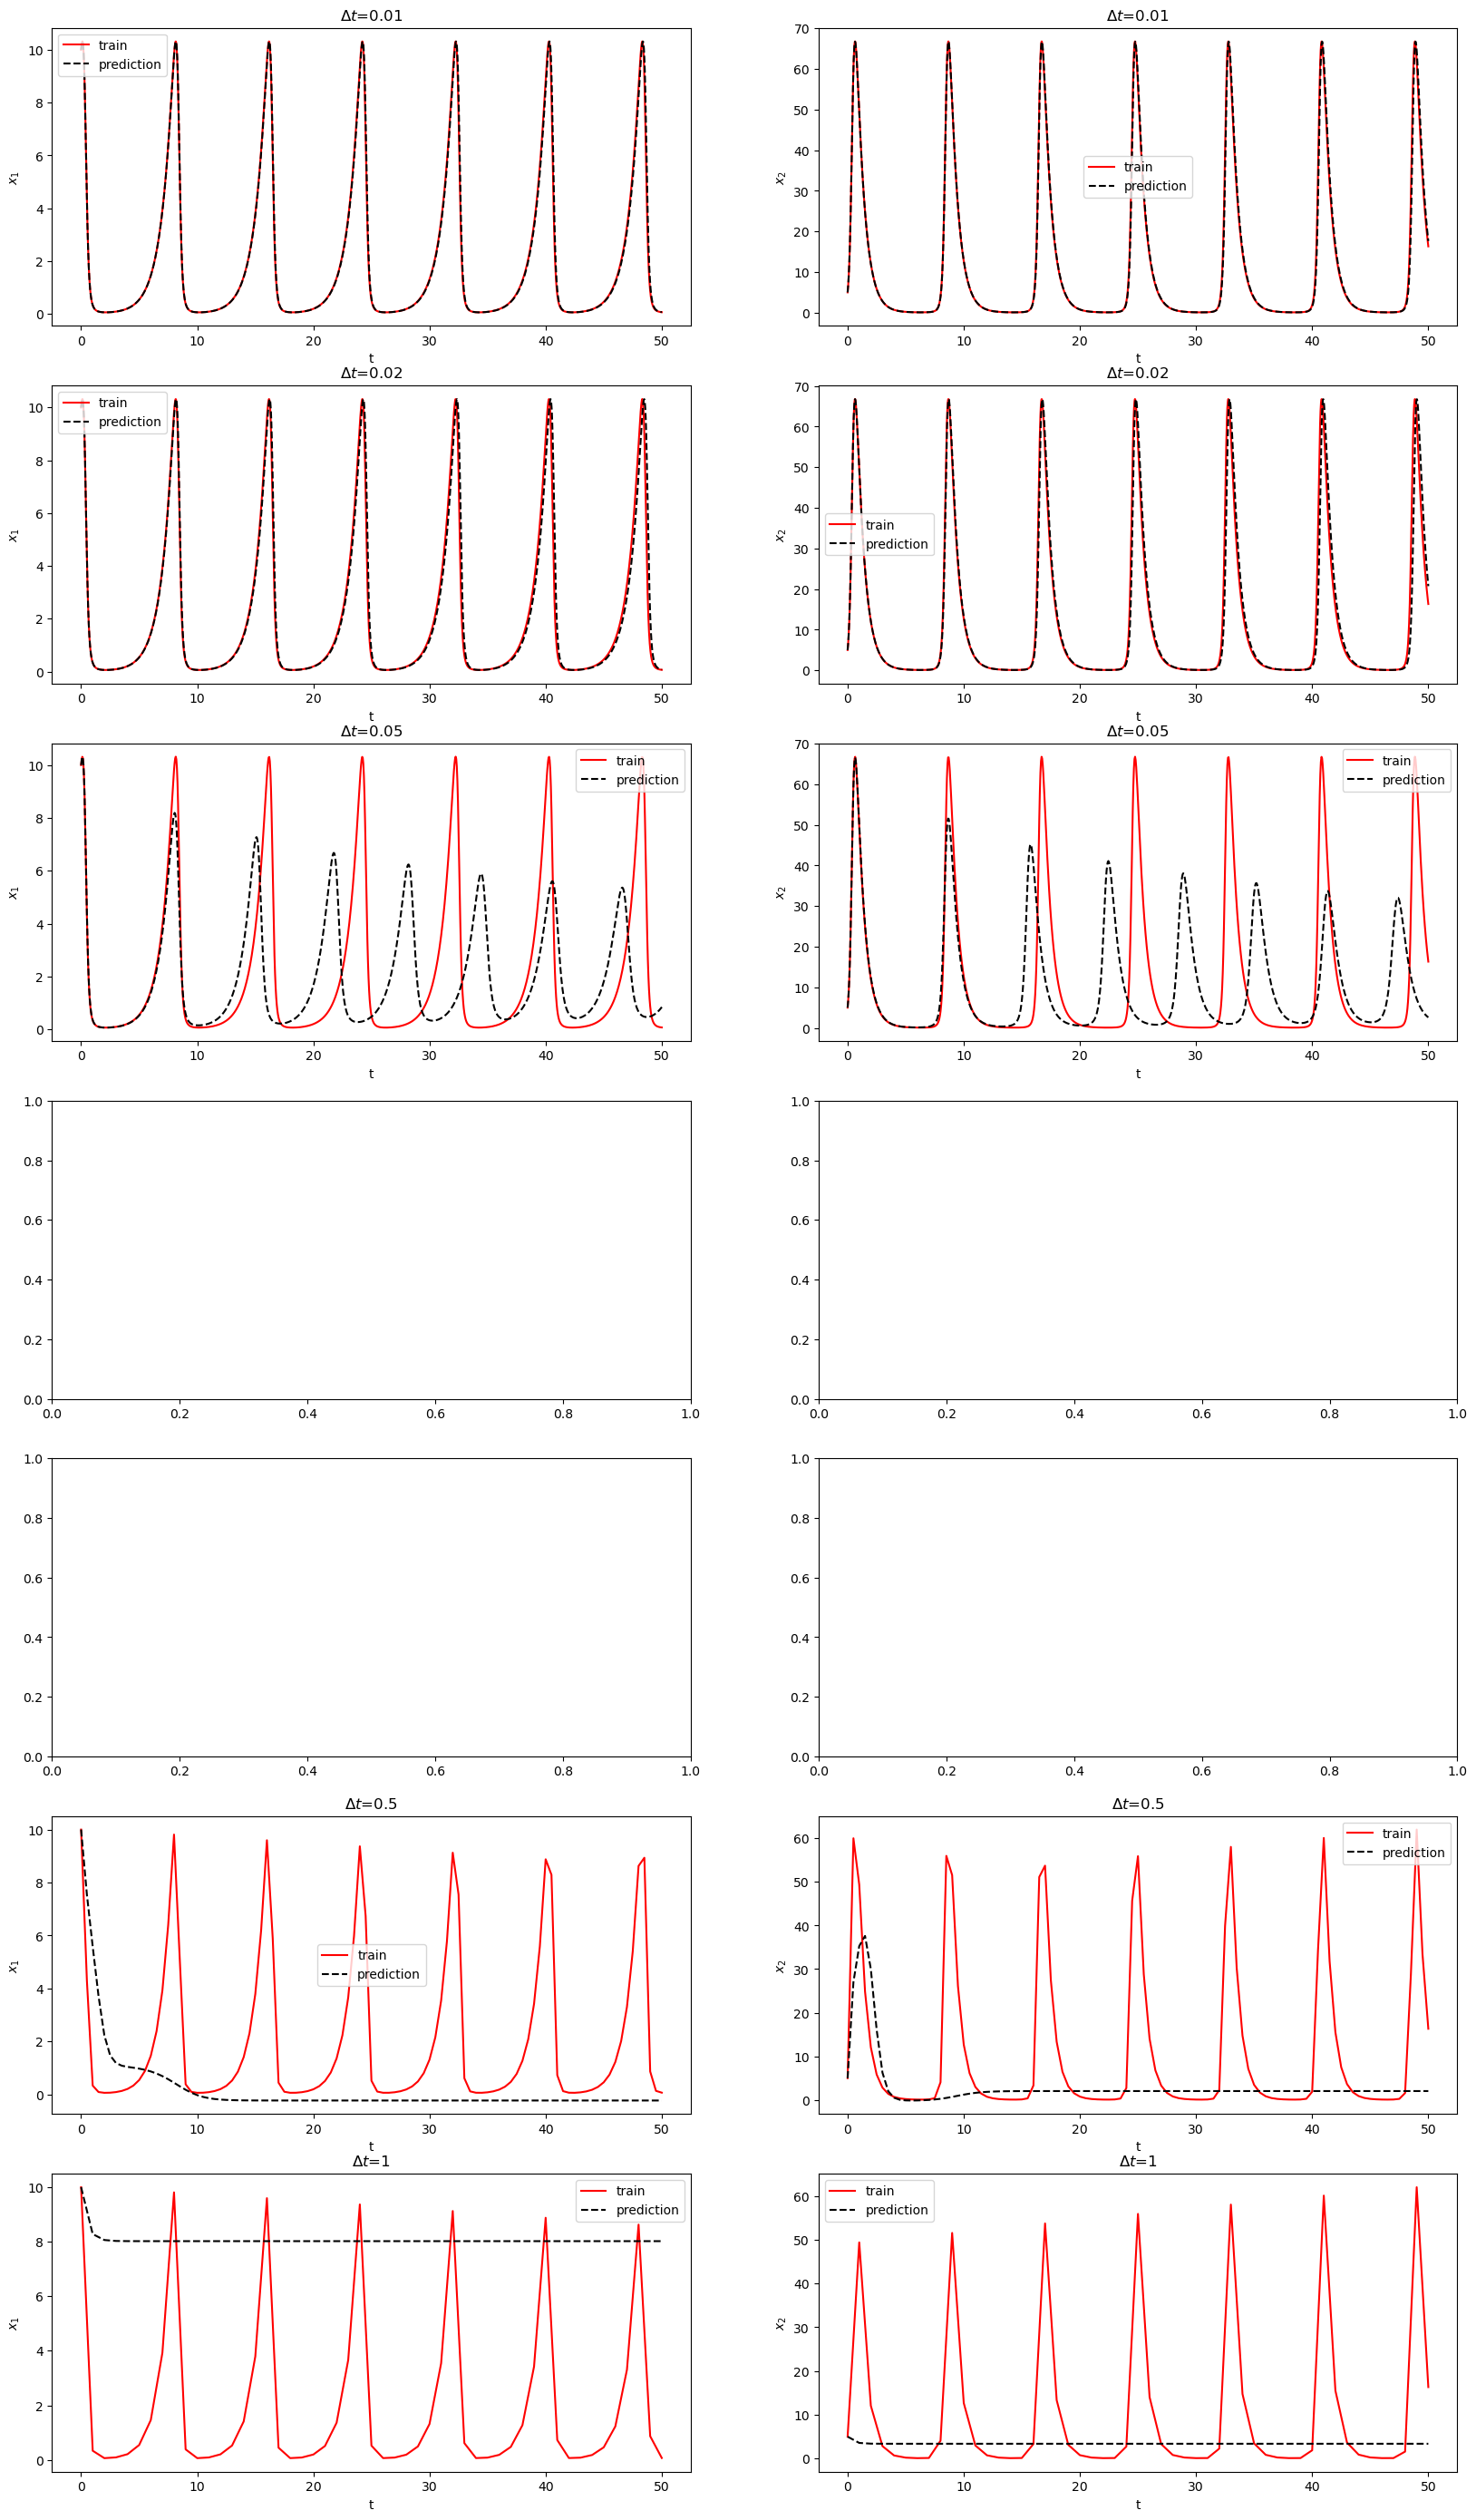

In [7]:
# plot the results
n_rows = len(dts)
n_cols = 2

fig, axs = plt.subplots(n_rows, n_cols, figsize=(10*n_cols, 5*n_rows))

for row in range(n_rows):
    # each row corresponds to a different noise level
    
    # skip if the model prediction failed
    if x_preds[row] is None:
        continue

    for col in range(n_cols):
        # plot the col'th training state variable
        axs[row, col].plot(t_evals[row], x_trains[row][col], "r", label="train")
        
        # plot the col'th state variable model prediction
        axs[row, col].plot(t_evals[row], x_preds[row][col], "k--", label="prediction")

        # set the title and labels
        axs[row, col].set_title(f"$\Delta t$={dts[row]}")
        axs[row, col].set_xlabel("t")
        axs[row, col].set_ylabel(f"$x_{col + 1}$")
        axs[row, col].legend()